# Acute Oral Toxicity 분류 모델 개발

**데이터 출처**: NTP Integrated Chemical Environment (ICE) — Acute Oral Toxicity (Rat LD50)  
**목표**: 화학물질의 2D molecular descriptor를 이용해 급성 경구독성 여부를 이진 분류

**레이블 정의**
- GHS 기준 LD50 ≤ 300 mg/kg → **Toxic (1)**
- LD50 > 300 mg/kg → **Non-toxic (0)**

---

## 전체 파이프라인

```
Step 1. 원본 데이터 전처리 (xlsx → 화합물별 중앙값 LD50 → GHS 이진 레이블)
Step 2. RDKit으로 2D descriptor 계산
Step 3. Train / Test 분리 (8:2, Stratified)
Step 4. Descriptor 전처리 (NaN 제거 → 저분산 제거 → 표준화) — Train 기준으로만 fit
Step 5. SelectKBest로 최적 k 탐색 — k별 CV & Test 점수 비교 그래프
Step 6. 모델 비교 (LogReg / MLP / SVM / DT / RF / XGBoost) — Train CV
Step 7. 최종 모델 Test 셋 평가 및 시각화
```

> ⚠️ **핵심 원칙**: Test 셋은 Step 7에서 딱 한 번만 사용. 모든 전처리·feature selection·하이퍼파라미터 튜닝은 Train 셋 안에서만.

---
# Step 1. 원본 데이터 전처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_excel('acute_oral.xlsx', sheet_name='Data')
print('원본 shape:', df_raw.shape)
print('Endpoint 종류:', df_raw['Endpoint'].value_counts().to_dict())

원본 shape: (16721, 23)
Endpoint 종류: {'LD50': 13512, 'GHS classification': 1611, 'EPA classification': 1598}


In [2]:
# LD50 + 단일화합물 + SMILES 있는 행만 선택
df_filtered = df_raw[
    (df_raw['Endpoint'] == 'LD50') &
    (df_raw['Mixture'] == 'Chemical') &
    (df_raw['SMILES'].notna())
].copy()
print('필터 후 shape:', df_filtered.shape)

필터 후 shape: (11948, 23)


In [3]:
# 화합물별 중앙값 LD50 계산
df_compound = df_filtered.groupby('CASRN').agg(
    LD50_median=('Response', 'median'),
    SMILES=('SMILES', 'first'),
    Chemical_Name=('Chemical_Name', 'first')
).reset_index()
print('중복 제거 후 고유 화합물 수:', len(df_compound))

중복 제거 후 고유 화합물 수: 8794


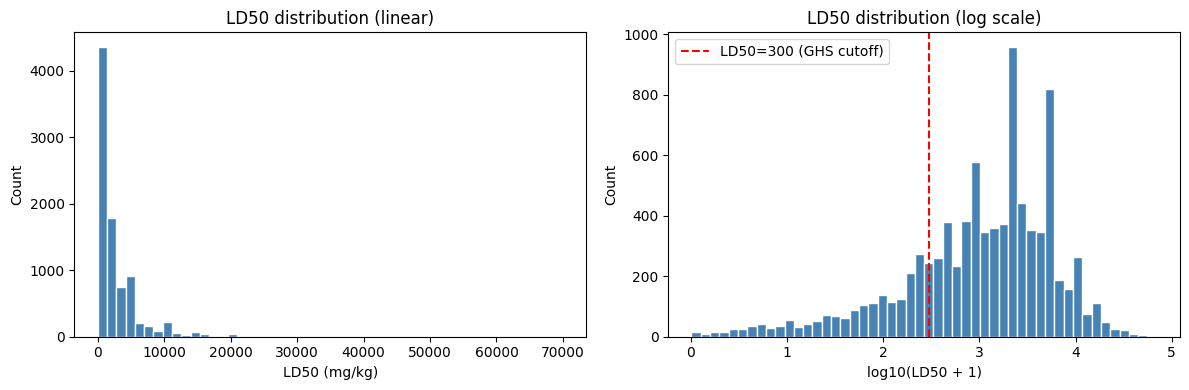

In [4]:
# LD50 분포 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_compound['LD50_median'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('LD50 (mg/kg)')
axes[0].set_ylabel('Count')
axes[0].set_title('LD50 distribution (linear)')

axes[1].hist(np.log10(df_compound['LD50_median'] + 1), bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(np.log10(300), color='red', linestyle='--', label='LD50=300 (GHS cutoff)')
axes[1].set_xlabel('log10(LD50 + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('LD50 distribution (log scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# GHS 이진 레이블 생성
# GHS Category 1-3: LD50 <= 300 mg/kg → Toxic (1)
# GHS Category 4-5: LD50 > 300 mg/kg  → Non-toxic (0)
df_compound['label'] = (df_compound['LD50_median'] <= 300).astype(int)

print('label 분포:')
print(df_compound['label'].value_counts())
print(f"Toxic 비율: {df_compound['label'].mean():.1%}")

label 분포:
label
0    6849
1    1945
Name: count, dtype: int64
Toxic 비율: 22.1%


---
# Step 2. RDKit으로 2D Descriptor 계산

SMILES → 분자 구조(mol) → 217개 2D descriptor 계산

**제외 조건**
- SMILES에 `.` 포함 → 단일 분자가 아님 (염, 혼합물 등)
- `MolFromSmiles()` 가 None → 유효하지 않은 SMILES

In [6]:
from rdkit import Chem
from rdkit.Chem import Descriptors

desc_names = [d[0] for d in Descriptors.descList]
desc_fns   = [d[1] for d in Descriptors.descList]
print('계산할 descriptor 수:', len(desc_names))

계산할 descriptor 수: 217


In [7]:
rows = []
skipped_dot     = 0
skipped_invalid = 0

for _, row in df_compound.iterrows():
    smi = row['SMILES']

    if '.' in smi:
        skipped_dot += 1
        continue

    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        skipped_invalid += 1
        continue

    vals = []
    for fn in desc_fns:
        try:
            vals.append(fn(mol))
        except:
            vals.append(np.nan)

    rows.append([
        row['CASRN'], row['Chemical_Name'], smi,
        row['LD50_median'], row['label']
    ] + vals)

cols = ['CASRN', 'Chemical_Name', 'standardized_smi', 'LD50_median', 'label'] + desc_names
df_desc = pd.DataFrame(rows, columns=cols)

print(f'제외 (점 포함): {skipped_dot}')
print(f'제외 (유효하지 않은 SMILES): {skipped_invalid}')
print(f'최종 shape: {df_desc.shape}')
print('label 분포:')
print(df_desc['label'].value_counts())

df_desc.to_csv('acute_oral_2Ddesc.csv', index=False)
print('저장 완료: acute_oral_2Ddesc.csv')

제외 (점 포함): 1481
제외 (유효하지 않은 SMILES): 4
최종 shape: (7309, 222)
label 분포:
label
0    5666
1    1643
Name: count, dtype: int64
저장 완료: acute_oral_2Ddesc.csv


---
# Step 3. Train / Test 분리

**Stratified split** 사용 — 클래스 비율(Toxic 22.5%)이 train/test 양쪽에 동일하게 유지

- **Train 80%** → 모델 학습 + CV 튜닝에만 사용
- **Test 20%** → Step 7 최종 평가에서 딱 한 번만 사용

In [8]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('acute_oral_2Ddesc.csv')
y  = df['label']
X  = df.drop(columns=['CASRN', 'Chemical_Name', 'standardized_smi', 'LD50_median', 'label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

print(f'Train: {X_train.shape[0]}개  (Toxic: {y_train.sum()}, Non-toxic: {(y_train==0).sum()})')
print(f'Test : {X_test.shape[0]}개  (Toxic: {y_test.sum()}, Non-toxic: {(y_test==0).sum()})')
print(f'\nTrain Toxic 비율: {y_train.mean():.1%}')
print(f'Test  Toxic 비율: {y_test.mean():.1%}')

Train: 5847개  (Toxic: 1314, Non-toxic: 4533)
Test : 1462개  (Toxic: 329, Non-toxic: 1133)

Train Toxic 비율: 22.5%
Test  Toxic 비율: 22.5%


---
# Step 4. Descriptor 전처리

**핵심 원칙: Train 셋으로만 fit → Train/Test 둘 다 transform**

Test 셋 정보가 전처리 과정에 새어 들어가지 않도록 한다. (data leakage 방지)

1. **NaN 열 제거** — train 기준으로 NaN 있는 열 제거
2. **저분산 열 제거** — train 기준 표준편차 0.01 미만 제거
3. **StandardScaler** — train으로 fit, train/test 모두 transform (선형 모델용)

In [9]:
# NaN 열 제거 — train 기준
nan_cols = X_train.columns[X_train.isna().any()]
X_train = X_train.drop(columns=nan_cols)
X_test  = X_test.drop(columns=nan_cols)
print('NaN 제거 후:', X_train.shape)

# 저분산 열 제거 — train 기준
low_var_cols = X_train.columns[X_train.std() < 0.01]
X_train = X_train.drop(columns=low_var_cols)
X_test  = X_test.drop(columns=low_var_cols)
print('저분산 제거 후:', X_train.shape)

NaN 제거 후: (5847, 205)
저분산 제거 후: (5847, 202)


In [10]:
from sklearn.preprocessing import StandardScaler

# train으로만 fit
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform만!

print('StandardScaler 완료')
print('X_train_scaled:', X_train_scaled.shape)
print('X_test_scaled :', X_test_scaled.shape)

StandardScaler 완료
X_train_scaled: (5847, 202)
X_test_scaled : (1462, 202)


---
# Step 5. SelectKBest로 최적 k 탐색

k(선택할 descriptor 수)를 바꿔가며 **CV 점수와 Test 점수를 동시에 확인**한다.

- CV 점수: Train 셋 안에서 StratifiedKFold(5) 평균
- Test 점수: 각 k에서 모델을 train 전체로 학습 후 test 셋 적용
- 지표: **Balanced Accuracy**, **ROC-AUC**, **F1 (macro)**

> CV와 Test 점수가 비슷하게 움직이면 → 일반화가 잘 되고 있다는 신호

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, f1_score

k_candidates = [5, 10, 20, 30, 40, 50, 70, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True)

records = []

for k in k_candidates:
    # selector는 train으로만 fit
    sel = SelectKBest(f_classif, k=k)
    Xtr = sel.fit_transform(X_train_scaled, y_train)
    Xte = sel.transform(X_test_scaled)   # transform만!

    clf = LogisticRegression(max_iter=1000)

    # CV 점수 — train 안에서만
    cv_bal = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='balanced_accuracy').mean()
    cv_auc = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    cv_f1  = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='f1_macro').mean()

    # Test 점수 — train 전체로 학습 후 test 적용
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    test_bal = balanced_accuracy_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_prob)
    test_f1  = f1_score(y_test, y_pred, average='macro')

    records.append({
        'k': k,
        'cv_balanced_acc': round(cv_bal, 3),  'test_balanced_acc': round(test_bal, 3),
        'cv_roc_auc':      round(cv_auc, 3),  'test_roc_auc':      round(test_auc, 3),
        'cv_f1_macro':     round(cv_f1, 3),   'test_f1_macro':     round(test_f1, 3),
    })
    print(f'k={k:3d}  bal_acc: CV={cv_bal:.3f} / Test={test_bal:.3f}  '
          f'auc: CV={cv_auc:.3f} / Test={test_auc:.3f}  '
          f'f1: CV={cv_f1:.3f} / Test={test_f1:.3f}')

k_df = pd.DataFrame(records)

best_k = int(k_df.loc[k_df['cv_balanced_acc'].idxmax(), 'k'])
print(f'\n최적 k: {best_k}  (CV Balanced Acc={k_df.loc[k_df["cv_balanced_acc"].idxmax(), "cv_balanced_acc"]:.3f})')

k=  5  bal_acc: CV=0.533 / Test=0.533  auc: CV=0.689 / Test=0.687  f1: CV=0.509 / Test=0.512
k= 10  bal_acc: CV=0.551 / Test=0.534  auc: CV=0.694 / Test=0.694  f1: CV=0.544 / Test=0.515
k= 20  bal_acc: CV=0.588 / Test=0.596  auc: CV=0.721 / Test=0.727  f1: CV=0.603 / Test=0.609
k= 30  bal_acc: CV=0.607 / Test=0.609  auc: CV=0.727 / Test=0.747  f1: CV=0.626 / Test=0.626
k= 40  bal_acc: CV=0.620 / Test=0.615  auc: CV=0.735 / Test=0.748  f1: CV=0.635 / Test=0.634
k= 50  bal_acc: CV=0.627 / Test=0.633  auc: CV=0.748 / Test=0.762  f1: CV=0.649 / Test=0.657
k= 70  bal_acc: CV=0.634 / Test=0.643  auc: CV=0.757 / Test=0.774  f1: CV=0.660 / Test=0.667
k=100  bal_acc: CV=0.653 / Test=0.657  auc: CV=0.772 / Test=0.789  f1: CV=0.672 / Test=0.683

최적 k: 100  (CV Balanced Acc=0.653)


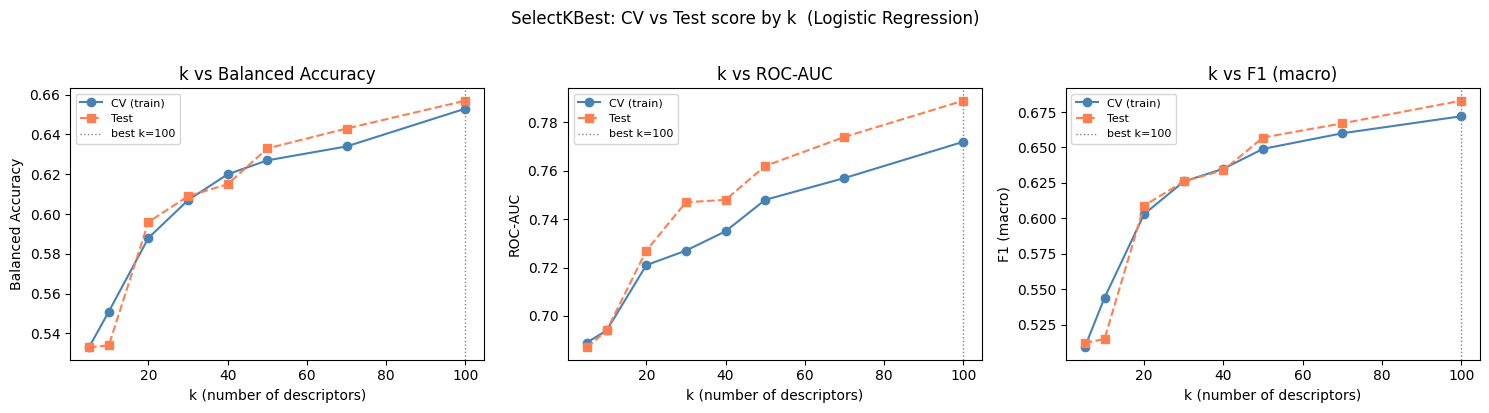

In [12]:
# k별 CV vs Test 점수 비교 그래프 (3가지 지표)
metrics = [
    ('balanced_acc', 'Balanced Accuracy'),
    ('roc_auc',      'ROC-AUC'),
    ('f1_macro',     'F1 (macro)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (metric, title) in zip(axes, metrics):
    ax.plot(k_df['k'], k_df[f'cv_{metric}'],
            marker='o', color='steelblue', label='CV (train)')
    ax.plot(k_df['k'], k_df[f'test_{metric}'],
            marker='s', color='coral',     label='Test', linestyle='--')
    ax.axvline(best_k, color='gray', linestyle=':', linewidth=1, label=f'best k={best_k}')
    ax.set_xlabel('k (number of descriptors)')
    ax.set_ylabel(title)
    ax.set_title(f'k vs {title}')
    ax.legend(fontsize=8)

plt.suptitle('SelectKBest: CV vs Test score by k  (Logistic Regression)', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# best_k로 train/test descriptor 선택
# selector는 train으로만 fit
selector = SelectKBest(f_classif, k=best_k)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)   # transform만!

# 트리 모델용 (표준화 없는 버전)
selector_tree = SelectKBest(f_classif, k=best_k)
X_train_tree = selector_tree.fit_transform(X_train, y_train)
X_test_tree  = selector_tree.transform(X_test)

selected_cols = X_train.columns[selector_tree.get_support()]
print('선택된 descriptor:')
print(list(selected_cols))

선택된 descriptor:
['MinEStateIndex', 'HeavyAtomMolWt', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BalabanJ', 'Chi0n', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Kappa2', 'PEOE_VSA1', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA8', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SlogP_VSA10', 'SlogP_VSA12', 'SlogP_VSA3', 'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA8', 'EState_VSA1', 'EState_VSA2', 'EState_VSA4', 'EState_VSA5', 'EState_VSA9', 'VSA_EState1', 'VSA_EState10', 'VSA_EState2', 'VSA_EState4', 'VSA_EState6', 'VSA_EState7', 'VSA_EState8', 'VSA_EState9', 'NHOHCount', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumHeterocycles', 'NumRotatableBonds', 'fr_Al_COO', 'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_Ar_OH', 'fr_COO', 'fr_COO2', 'fr_C_O', 'fr_C_O_noCOO', 'fr_C_S', 'fr_NH0', 'fr_NH2', 'fr_Nhpyrrole', 'fr_aldehyde', 'fr_alkyl_

---
# Step 6. 모델 비교 — Train CV

6가지 모델을 **Train 셋 안에서 StratifiedKFold CV**로 비교한다.

- 클래스 불균형 → `balanced_accuracy` 를 주 지표로 사용
- 트리 모델(DT, RF, XGB)은 표준화 없는 `X_train_tree` 사용
- Test 셋은 이 단계에서 절대 사용하지 않는다

In [14]:
# Logistic Regression — C 탐색
from sklearn.linear_model import LogisticRegression

print('=== Logistic Regression ===')
for C in [0.001, 0.01, 0.1, 1, 10]:
    clf = LogisticRegression(C=C, max_iter=1000)
    score = cross_val_score(clf, X_train_sel, y_train,
                            cv=cv, scoring='balanced_accuracy').mean()
    print(f'C={C:.3f}  CV Balanced Acc={score:.3f}')

=== Logistic Regression ===
C=0.001  CV Balanced Acc=0.558
C=0.010  CV Balanced Acc=0.630
C=0.100  CV Balanced Acc=0.648
C=1.000  CV Balanced Acc=0.654
C=10.000  CV Balanced Acc=0.651


In [15]:
# MLP — hidden layer 탐색
from sklearn.neural_network import MLPClassifier

print('=== MLP ===')
for hs in [(50,), (100,), (100, 50), (200, 100)]:
    clf = MLPClassifier(hidden_layer_sizes=hs, max_iter=500)
    score = cross_val_score(clf, X_train_sel, y_train,
                            cv=cv, scoring='balanced_accuracy').mean()
    print(f'hidden={str(hs):15s}  CV Balanced Acc={score:.3f}')

=== MLP ===
hidden=(50,)            CV Balanced Acc=0.737
hidden=(100,)           CV Balanced Acc=0.744
hidden=(100, 50)        CV Balanced Acc=0.749
hidden=(200, 100)       CV Balanced Acc=0.740


In [16]:
# SVM — C × kernel 탐색
from sklearn.svm import SVC

print('=== SVM ===')
for C in [0.1, 1, 10]:
    for kernel in ['linear', 'rbf']:
        clf = SVC(C=C, kernel=kernel)
        score = cross_val_score(clf, X_train_sel, y_train,
                                cv=cv, scoring='balanced_accuracy').mean()
        print(f'C={C:4.1f}  kernel={kernel:6s}  CV Balanced Acc={score:.3f}')

=== SVM ===
C= 0.1  kernel=linear  CV Balanced Acc=0.637
C= 0.1  kernel=rbf     CV Balanced Acc=0.575
C= 1.0  kernel=linear  CV Balanced Acc=0.641
C= 1.0  kernel=rbf     CV Balanced Acc=0.674
C=10.0  kernel=linear  CV Balanced Acc=0.646
C=10.0  kernel=rbf     CV Balanced Acc=0.737


In [17]:
# Decision Tree — max_depth × min_samples_split 탐색
from sklearn.tree import DecisionTreeClassifier

print('=== Decision Tree ===')
for d in [2, 3, 5, None]:
    for s in [2, 4, 6]:
        clf = DecisionTreeClassifier(max_depth=d, min_samples_split=s)
        score = cross_val_score(clf, X_train_tree, y_train,
                                cv=cv, scoring='balanced_accuracy').mean()
        print(f'max_depth={str(d):4s}  min_split={s}  CV Balanced Acc={score:.3f}')

=== Decision Tree ===
max_depth=2     min_split=2  CV Balanced Acc=0.617
max_depth=2     min_split=4  CV Balanced Acc=0.617
max_depth=2     min_split=6  CV Balanced Acc=0.619
max_depth=3     min_split=2  CV Balanced Acc=0.631
max_depth=3     min_split=4  CV Balanced Acc=0.637
max_depth=3     min_split=6  CV Balanced Acc=0.600
max_depth=5     min_split=2  CV Balanced Acc=0.650
max_depth=5     min_split=4  CV Balanced Acc=0.669
max_depth=5     min_split=6  CV Balanced Acc=0.662
max_depth=None  min_split=2  CV Balanced Acc=0.697
max_depth=None  min_split=4  CV Balanced Acc=0.703
max_depth=None  min_split=6  CV Balanced Acc=0.699


In [18]:
# Random Forest — n_estimators × max_depth 탐색
from sklearn.ensemble import RandomForestClassifier

print('=== Random Forest ===')
for n in [50, 100, 200]:
    for d in [3, 5, 7, None]:
        clf = RandomForestClassifier(n_estimators=n, max_depth=d)
        score = cross_val_score(clf, X_train_tree, y_train,
                                cv=cv, scoring='balanced_accuracy').mean()
        print(f'n={n:3d}  max_depth={str(d):4s}  CV Balanced Acc={score:.3f}')

=== Random Forest ===
n= 50  max_depth=3     CV Balanced Acc=0.544
n= 50  max_depth=5     CV Balanced Acc=0.604
n= 50  max_depth=7     CV Balanced Acc=0.643
n= 50  max_depth=None  CV Balanced Acc=0.715
n=100  max_depth=3     CV Balanced Acc=0.545
n=100  max_depth=5     CV Balanced Acc=0.599
n=100  max_depth=7     CV Balanced Acc=0.646
n=100  max_depth=None  CV Balanced Acc=0.715
n=200  max_depth=3     CV Balanced Acc=0.542
n=200  max_depth=5     CV Balanced Acc=0.604
n=200  max_depth=7     CV Balanced Acc=0.643
n=200  max_depth=None  CV Balanced Acc=0.715


In [19]:
# XGBoost — n_estimators × max_depth × learning_rate 탐색
from xgboost import XGBClassifier

print('=== XGBoost ===')
for n in [50, 100, 200]:
    for d in [3, 5, 7]:
        for lr in [0.05, 0.1, 0.3]:
            clf = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=lr,
                                eval_metric='logloss', verbosity=0)
            score = cross_val_score(clf, X_train_tree, y_train,
                                    cv=cv, scoring='balanced_accuracy').mean()
            print(f'n={n:3d}  depth={d}  lr={lr:.2f}  CV Balanced Acc={score:.3f}')

=== XGBoost ===
n= 50  depth=3  lr=0.05  CV Balanced Acc=0.613
n= 50  depth=3  lr=0.10  CV Balanced Acc=0.645
n= 50  depth=3  lr=0.30  CV Balanced Acc=0.693
n= 50  depth=5  lr=0.05  CV Balanced Acc=0.657
n= 50  depth=5  lr=0.10  CV Balanced Acc=0.689
n= 50  depth=5  lr=0.30  CV Balanced Acc=0.718
n= 50  depth=7  lr=0.05  CV Balanced Acc=0.687
n= 50  depth=7  lr=0.10  CV Balanced Acc=0.713
n= 50  depth=7  lr=0.30  CV Balanced Acc=0.730
n=100  depth=3  lr=0.05  CV Balanced Acc=0.645
n=100  depth=3  lr=0.10  CV Balanced Acc=0.675
n=100  depth=3  lr=0.30  CV Balanced Acc=0.723
n=100  depth=5  lr=0.05  CV Balanced Acc=0.689
n=100  depth=5  lr=0.10  CV Balanced Acc=0.712
n=100  depth=5  lr=0.30  CV Balanced Acc=0.731
n=100  depth=7  lr=0.05  CV Balanced Acc=0.706
n=100  depth=7  lr=0.10  CV Balanced Acc=0.723
n=100  depth=7  lr=0.30  CV Balanced Acc=0.734
n=200  depth=3  lr=0.05  CV Balanced Acc=0.667
n=200  depth=3  lr=0.10  CV Balanced Acc=0.696
n=200  depth=3  lr=0.30  CV Balanced Acc=0.7

In [20]:
# 전체 모델 CV 점수 정리
# 위 grid search에서 찾은 최적 하이퍼파라미터로 설정 (직접 결과 보고 수정)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

model_configs = {
    'LogReg': (LogisticRegression(C=0.1, max_iter=1000),             X_train_sel,  X_test_sel),
    'MLP':    (MLPClassifier(hidden_layer_sizes=(100,), max_iter=500), X_train_sel, X_test_sel),
    'SVM':    (SVC(C=1, kernel='rbf', probability=True),              X_train_sel,  X_test_sel),
    'DT':     (DecisionTreeClassifier(max_depth=5),                   X_train_tree, X_test_tree),
    'RF':     (RandomForestClassifier(n_estimators=100, max_depth=5), X_train_tree, X_test_tree),
    'XGB':    (XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                             eval_metric='logloss', verbosity=0),     X_train_tree, X_test_tree),
}

results_cv = []
for name, (clf, Xtr, _) in model_configs.items():
    score = cross_val_score(clf, Xtr, y_train,
                            cv=cv, scoring='balanced_accuracy').mean()
    results_cv.append({'model': name, 'cv_balanced_acc': round(score, 3)})
    print(f'{name:8s}  CV Balanced Acc={score:.3f}')

results_cv_df = pd.DataFrame(results_cv).sort_values('cv_balanced_acc', ascending=False)
print('\n=== CV 기준 모델 순위 ===')
print(results_cv_df.to_string(index=False))

LogReg    CV Balanced Acc=0.647
MLP       CV Balanced Acc=0.748
SVM       CV Balanced Acc=0.673
DT        CV Balanced Acc=0.656
RF        CV Balanced Acc=0.604
XGB       CV Balanced Acc=0.709

=== CV 기준 모델 순위 ===
 model  cv_balanced_acc
   MLP            0.748
   XGB            0.709
   SVM            0.673
    DT            0.656
LogReg            0.647
    RF            0.604


---
# Step 7. 최종 모델 Test 셋 평가

**CV 점수가 가장 높은 모델**을 선택해 전체 Train 셋으로 학습 후 Test 셋으로 최종 평가.

Test 셋은 여기서 처음이자 마지막으로 사용한다.

**평가 지표**
- **Balanced Accuracy** — 클래스 불균형 상황에서 신뢰할 수 있는 정확도
- **ROC-AUC** — 분류 경계 기준에 무관한 모델의 전반적 판별력
- **F1 (macro)** — Toxic / Non-toxic 두 클래스 평균 F1

In [21]:
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score,
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

final_results = []

for name, (clf, Xtr, Xte) in model_configs.items():
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)

    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(Xte)[:, 1]
    else:
        y_prob = clf.decision_function(Xte)

    final_results.append({
        'model':        name,
        'balanced_acc': round(balanced_accuracy_score(y_test, y_pred), 3),
        'accuracy':     round(accuracy_score(y_test, y_pred), 3),
        'roc_auc':      round(roc_auc_score(y_test, y_prob), 3),
        'f1_macro':     round(f1_score(y_test, y_pred, average='macro'), 3),
    })

final_df = pd.DataFrame(final_results).sort_values('balanced_acc', ascending=False)
print('=== Test 셋 최종 평가 결과 ===')
print(final_df.to_string(index=False))

=== Test 셋 최종 평가 결과 ===
 model  balanced_acc  accuracy  roc_auc  f1_macro
   MLP         0.748     0.828    0.827     0.750
   XGB         0.711     0.852    0.866     0.745
   SVM         0.676     0.843    0.829     0.711
    DT         0.669     0.826    0.723     0.696
LogReg         0.652     0.819    0.787     0.677
    RF         0.613     0.822    0.795     0.634


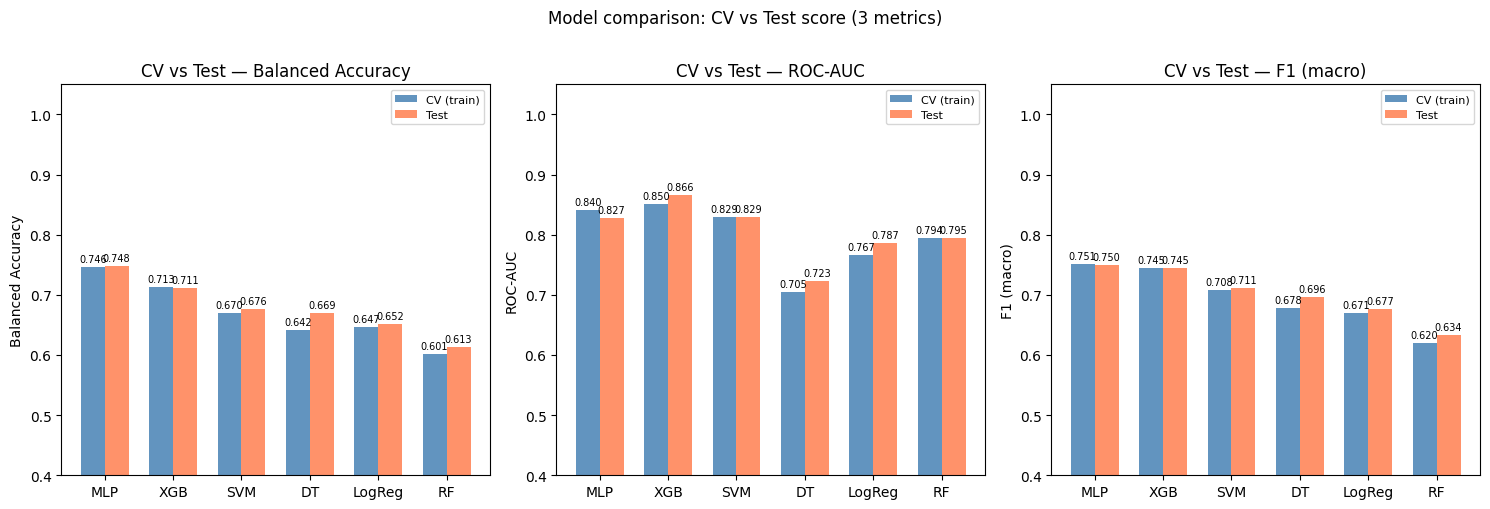

In [22]:
# 그래프 1 — 모델별 CV vs Test 점수 비교 (3가지 지표)
# 모델별로 CV와 Test 점수를 함께 보여줘 일반화 여부를 한눈에 확인
metrics_info = [
    ('cv_balanced_acc', 'balanced_acc', 'Balanced Accuracy'),
    ('cv_roc_auc',      'roc_auc',      'ROC-AUC'),
    ('cv_f1_macro',     'f1_macro',     'F1 (macro)'),
]

# CV 점수를 results_cv_df에서 가져와 final_df와 합치기
# Step 6에서 계산한 model_configs 기준 CV 재계산
cv_detail = []
for name, (clf, Xtr, _) in model_configs.items():
    bal = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='balanced_accuracy').mean()
    auc = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    f1  = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='f1_macro').mean()
    cv_detail.append({'model': name, 'cv_balanced_acc': bal,
                      'cv_roc_auc': auc, 'cv_f1_macro': f1})

cv_detail_df = pd.DataFrame(cv_detail)
compare_df   = final_df.merge(cv_detail_df, on='model')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (cv_col, test_col, title) in zip(axes, metrics_info):
    x      = np.arange(len(compare_df))
    width  = 0.35
    bars1  = ax.bar(x - width/2, compare_df[cv_col],   width,
                    color='steelblue', alpha=0.85, label='CV (train)')
    bars2  = ax.bar(x + width/2, compare_df[test_col], width,
                    color='coral',     alpha=0.85, label='Test')
    ax.set_xticks(x)
    ax.set_xticklabels(compare_df['model'])
    ax.set_ylabel(title)
    ax.set_title(f'CV vs Test — {title}')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=8)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model comparison: CV vs Test score (3 metrics)', y=1.01)
plt.tight_layout()
plt.show()

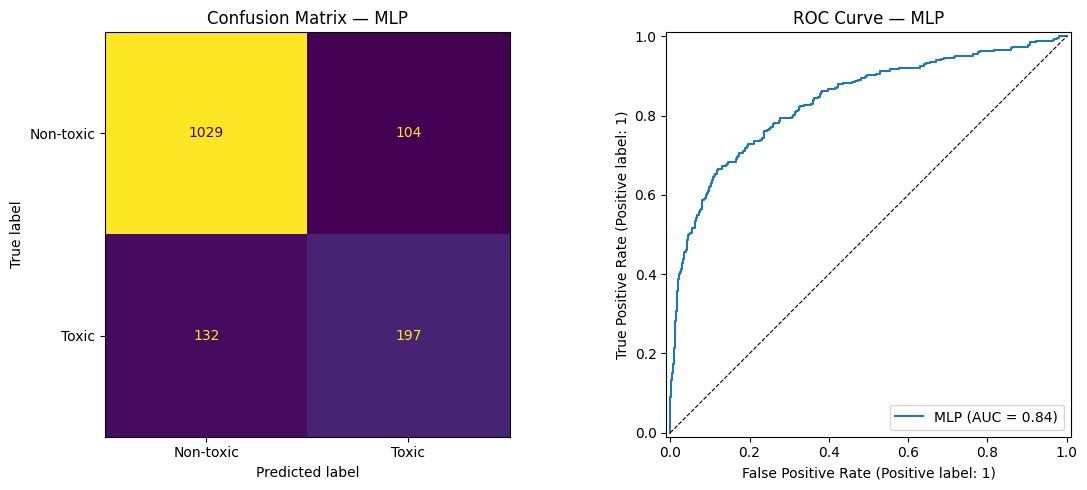


=== MLP Classification Report ===
              precision    recall  f1-score   support

   Non-toxic       0.89      0.91      0.90      1133
       Toxic       0.65      0.60      0.63       329

    accuracy                           0.84      1462
   macro avg       0.77      0.75      0.76      1462
weighted avg       0.83      0.84      0.84      1462



In [23]:
# 그래프 2 — 최고 모델 Confusion Matrix + ROC Curve
best_model_name = final_df.iloc[0]['model']
best_clf, best_Xtr, best_Xte = model_configs[best_model_name]

best_clf.fit(best_Xtr, y_train)
y_pred_best = best_clf.predict(best_Xte)
if hasattr(best_clf, 'predict_proba'):
    y_prob_best = best_clf.predict_proba(best_Xte)[:, 1]
else:
    y_prob_best = best_clf.decision_function(best_Xte)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Non-toxic', 'Toxic'],
    ax=axes[0], colorbar=False
)
axes[0].set_title(f'Confusion Matrix — {best_model_name}')

RocCurveDisplay.from_predictions(
    y_test, y_prob_best, ax=axes[1], name=best_model_name
)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title(f'ROC Curve — {best_model_name}')

plt.tight_layout()
plt.show()

print(f'\n=== {best_model_name} Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=['Non-toxic', 'Toxic']))

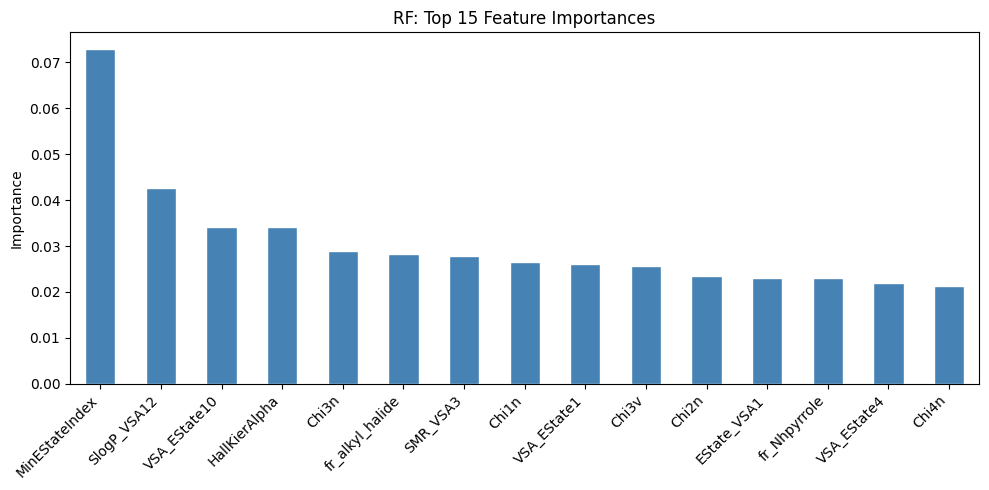

Top 10 important descriptors:
MinEStateIndex     0.072901
SlogP_VSA12        0.042677
VSA_EState10       0.034216
HallKierAlpha      0.034055
Chi3n              0.029024
fr_alkyl_halide    0.028212
SMR_VSA3           0.027753
Chi1n              0.026499
VSA_EState1        0.025997
Chi3v              0.025604


In [24]:
# 그래프 3 — Feature Importance (RF 또는 XGB)
fi_model_name = 'RF'
fi_clf, fi_Xtr, _ = model_configs[fi_model_name]
fi_clf.fit(fi_Xtr, y_train)

feat_imp = pd.Series(
    fi_clf.feature_importances_,
    index=selected_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title(f'{fi_model_name}: Top 15 Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 important descriptors:')
print(feat_imp.head(10).to_string())

---
## 결과 요약

| 모델 | Balanced Acc | ROC-AUC | F1 (macro) |
|------|-------------|---------|------------|
| Logistic Regression | - | - | - |
| MLP | - | - | - |
| SVM | - | - | - |
| Decision Tree | - | - | - |
| Random Forest | - | - | - |
| XGBoost | - | - | - |

> 직접 실행 결과로 채울 것

**관찰 포인트**
- CV와 Test 점수 차이가 크면 → overfitting 의심
- Accuracy가 높아도 Balanced Accuracy가 낮으면 → Non-toxic만 잘 맞히고 Toxic을 놓치는 것
- 앙상블(RF, XGB) vs 단일 트리(DT) 성능 차이 → 앙상블의 효과
- Feature importance 상위 descriptor → 어떤 분자 특성이 독성과 연관되는지 해석 가능